In [1]:
import numpy as np
from DNN.lw_spacenet import UNet3D
import torch 
import gc
import util.filehandler as fh
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

/tmp/ipykernel_6986/588083260.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


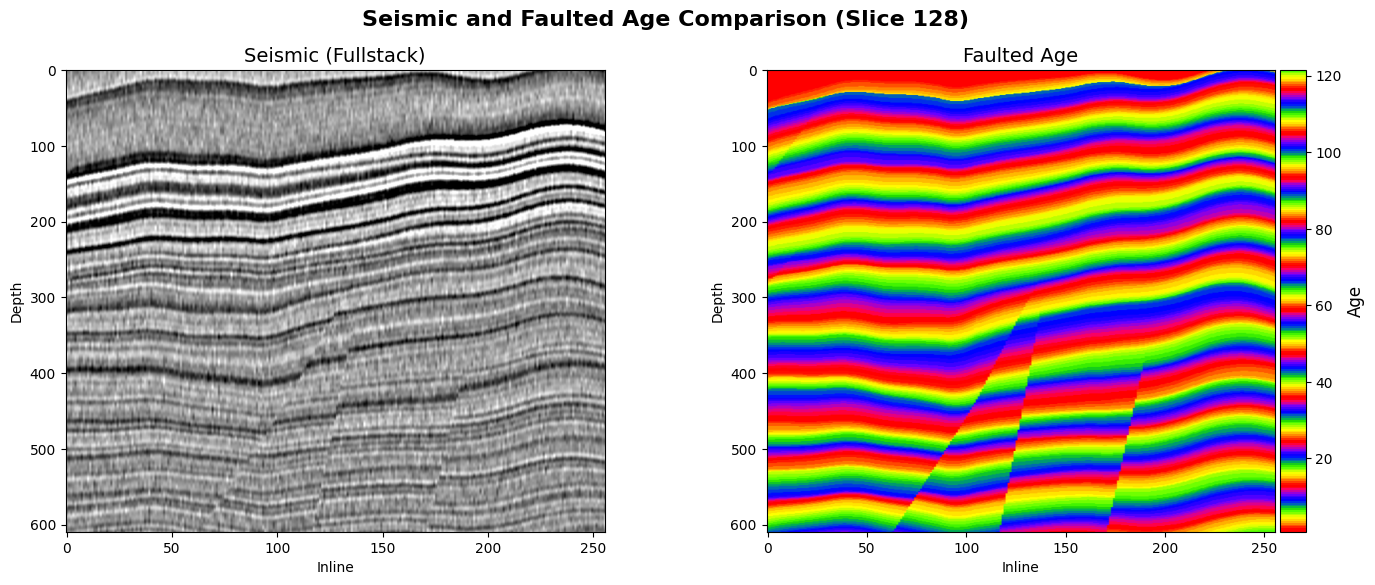

In [2]:
data_dir = '/mnt/neogen-garbage/storage_backup/nnseismic/synthetic_data/raw/seismic__2026.33698898'

seismic = np.load(f'{data_dir}/seismicCubes_cumsum_fullstack_2026.33698898.npy')
faulted_age = np.load(f'{data_dir}/faulted_age_2026.33698898.npy')

seismic_slice = seismic[128, :, 190:800].T
age_slice = faulted_age[128, :, 190:800].T

p2, p98 = np.percentile(seismic_slice, [2, 98])
seismic_amp = np.clip(seismic_slice, p2, p98)

fig, axs = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.3})

im0 = axs[0].imshow(seismic_amp, cmap='gray', aspect='auto')
axs[0].set_title('Seismic (Fullstack)', fontsize=14)
axs[0].set_xlabel('Inline')
axs[0].set_ylabel('Depth')

im1 = axs[1].imshow(age_slice, cmap='prism', aspect='auto')
axs[1].set_title('Faulted Age', fontsize=14)
axs[1].set_xlabel('Inline')
axs[1].set_ylabel('Depth')

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(axs[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = plt.colorbar(im1, cax=cax)
cbar.set_label('Age', fontsize=12)

fig.suptitle('Seismic and Faulted Age Comparison (Slice 128)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

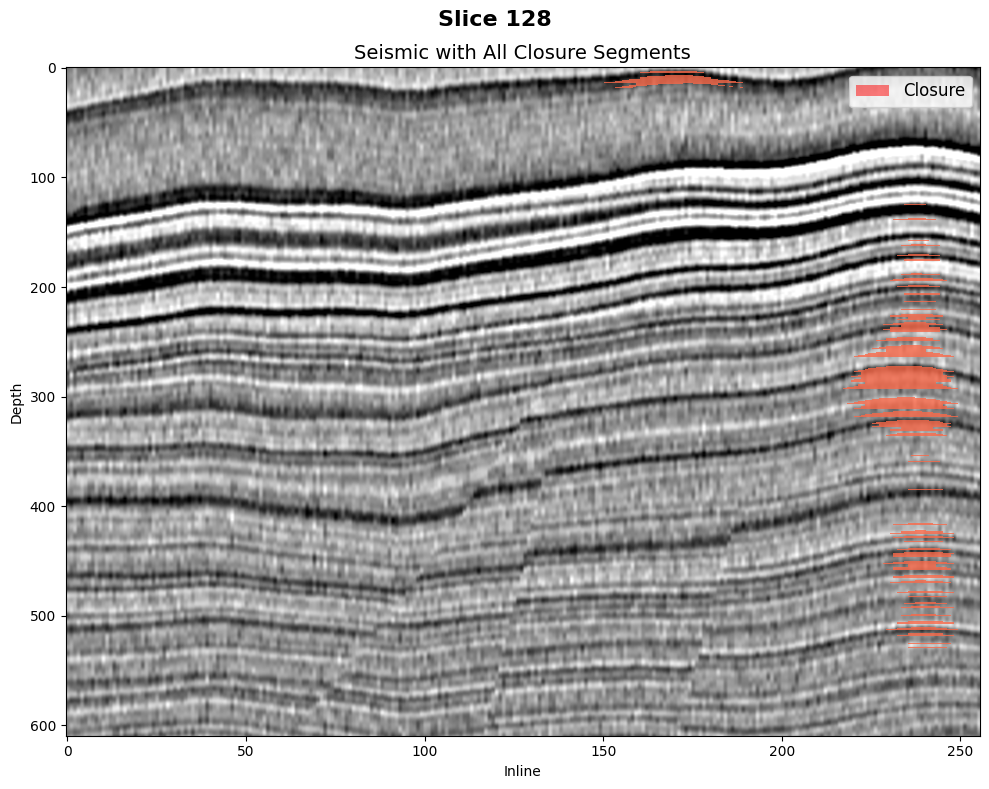

In [61]:
seismic = np.load(f'{data_dir}/seismicCubes_cumsum_fullstack_2026.33698898.npy')
all_closures = np.load(f'{data_dir}/all_closure_segments_2026.33698898.npy')

seismic_slice = seismic[128, :, 190:800].T
closures_slice = all_closures[128, :, 190:800].T

p2, p98 = np.percentile(seismic_slice, [2, 98])
seismic_amp = np.clip(seismic_slice, p2, p98)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.imshow(seismic_amp, cmap='gray', aspect='auto')

closures_masked = np.ma.masked_where(closures_slice == 0, closures_slice)
ax.imshow(closures_masked, cmap='Reds', aspect='auto', vmin=0, vmax=2, alpha=0.8)

ax.set_title('Seismic with All Closure Segments', fontsize=14)
ax.set_xlabel('Inline')
ax.set_ylabel('Depth')

legend_elements = [mpatches.Patch(facecolor='red', alpha=0.5, label='Closure')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

fig.suptitle('Slice 128', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

IndexError: index 260 is out of bounds for axis 0 with size 256

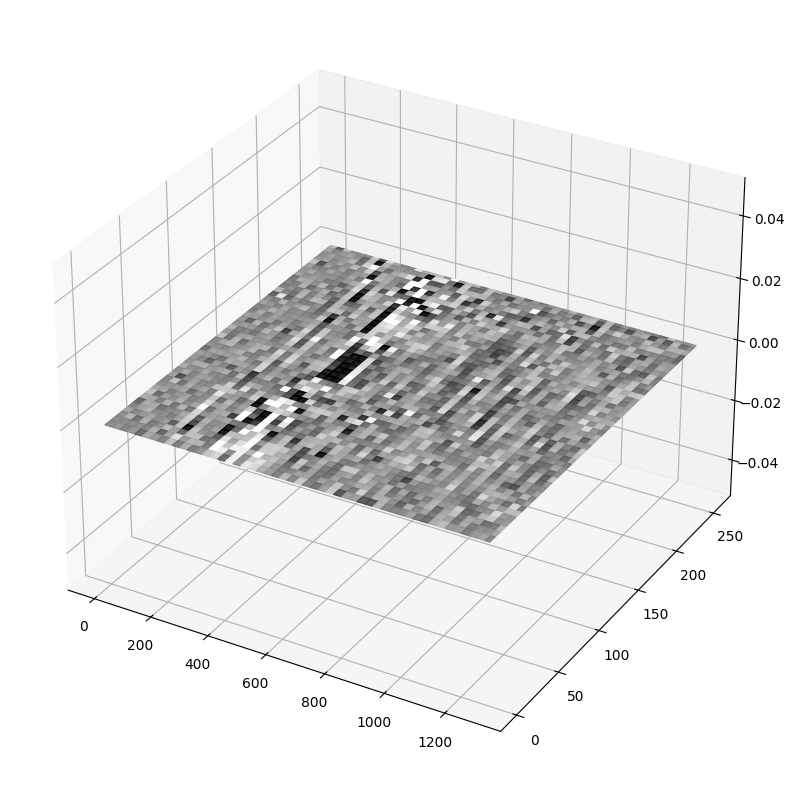

In [3]:
# For interactive 3D seismic cube visualization, use the dedicated viewer:
# Run: python util/3d_cube_viewer.py
# This script uses Plotly for high-quality, interactive 3D rendering
# You can edit the SEISMIC_FILEPATH variable in the script to change the data source

In [2]:
def load_model(checkpoint_path, device='cuda', smoothing_kernel_size=5):
    """Load trained model from checkpoint."""
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    model = UNet3D(in_channels=1, out_channels=1, init_features=16, smoothing_kernel_size=smoothing_kernel_size)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = model.bfloat16().to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model, device

In [6]:
model, device = load_model('../data/DNN models/run-20260404_152544/best_model.pth', smoothing_kernel_size=3)

# Export model to ONNX format for Netron visualization
dummy_input = torch.randn(1, 1, 128, 128, 128, dtype=torch.bfloat16, device=device)

torch.onnx.export(model, dummy_input, "unet_model.onnx", opset_version=11)

# Simplify
onnx_model = onnx.load("unet_model.onnx")
simplified, _ = simplify(onnx_model)
onnx.save(simplified, "unet_model_simple.onnx")

/tmp/ipykernel_21205/2660126185.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)
/home/spaceswimmer/minicond

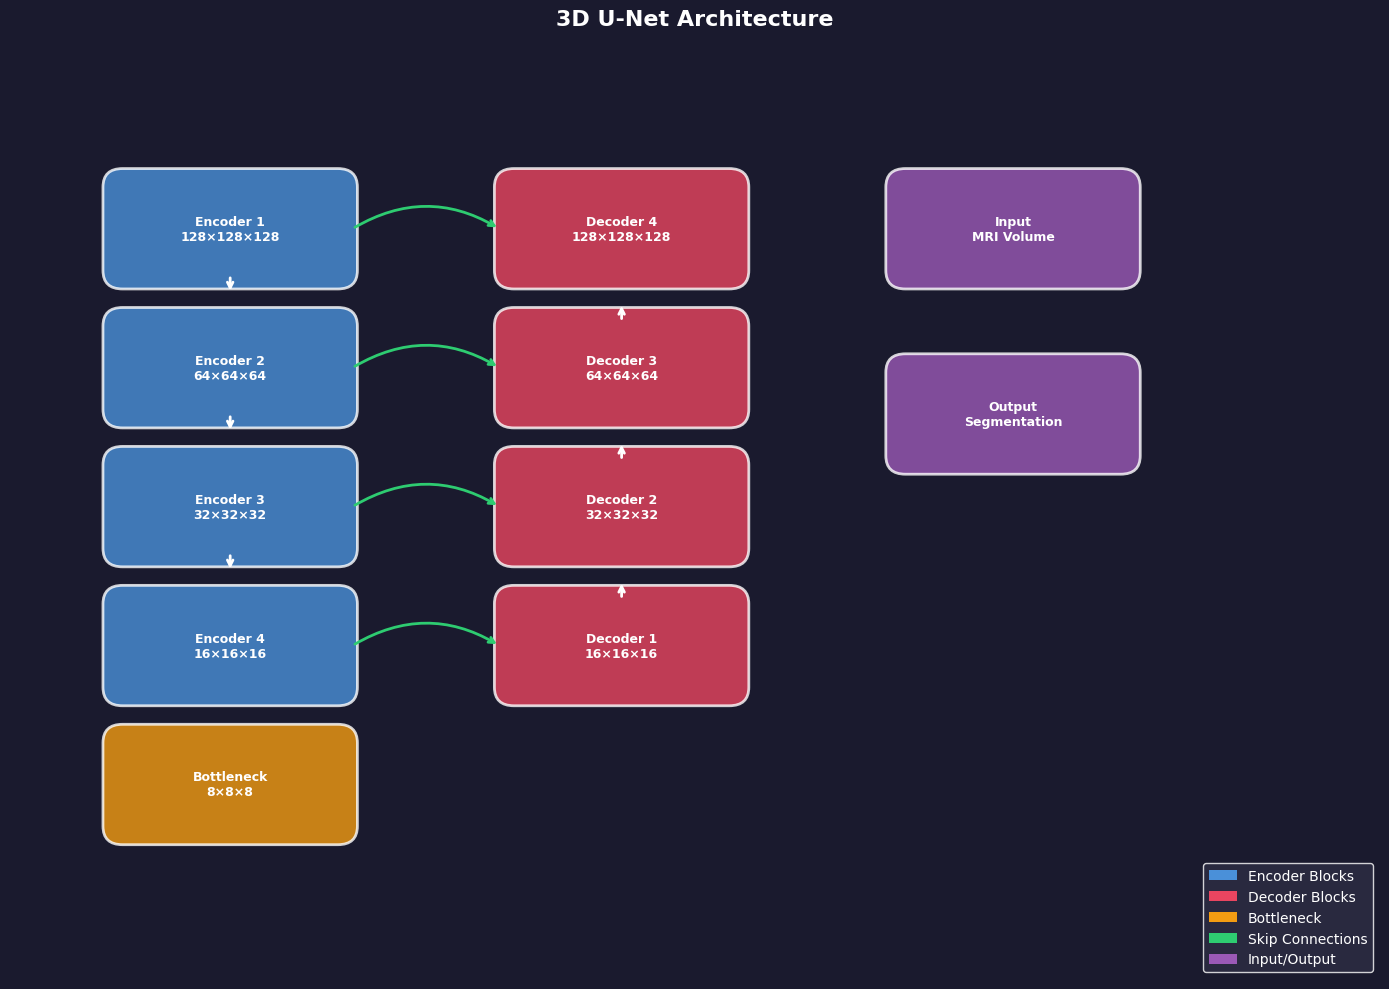

In [13]:
def plot_unet_architecture(model, input_shape=(1, 1, 128, 128, 128), save_path=None):
    """
    Create a beautiful U-Net architecture diagram.
    
    Args:
        model: The U-Net model to visualize
        input_shape: Input tensor shape (batch, channels, depth, height, width)
        save_path: Optional path to save the figure
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#1a1a2e')
    
    # Colors for different components
    colors = {
        'encoder': '#4a90d9',
        'decoder': '#e94560', 
        'bottleneck': '#f39c12',
        'skip': '#2ecc71',
        'input_output': '#9b59b6'
    }
    
    # Helper function to draw blocks
    def draw_block(x, y, width, height, label, color, alpha=0.8):
        # ... existing code ...
        block = FancyBboxPatch((x, y), width, height,
                               boxstyle="round,pad=0.05,rounding_size=0.2",
                               facecolor=color, edgecolor='white', 
                               linewidth=2, alpha=alpha)
        ax.add_patch(block)
        ax.text(x + width/2, y + height/2, label, 
                ha='center', va='center', fontsize=9, 
                color='white', fontweight='bold')
    
    # Calculate dimensions dynamically from input_shape
    _, _, d, h, w = input_shape
    levels = [
        f"{d}×{h}×{w}",           # Level 0 (Input/Enc 1)
        f"{d//2}×{h//2}×{w//2}",   # Level 1 (Enc 2)
        f"{d//4}×{h//4}×{w//4}",   # Level 2 (Enc 3)
        f"{d//8}×{h//8}×{w//8}",   # Level 3 (Enc 4)
        f"{d//16}×{h//16}×{w//16}" # Level 4 (Bottleneck)
    ]
    
    # Draw encoder path (left side)
    encoder_positions = [(1, 7.5), (1, 6), (1, 4.5), (1, 3)]
    encoder_labels = [f'Encoder {i+1}\n{levels[i]}' for i in range(4)]
    
    for i, ((x, y), label) in enumerate(zip(encoder_positions, encoder_labels)):
        # ... existing code ...
        draw_block(x, y, 2.5, 1.2, label, colors['encoder'])
        if i < len(encoder_positions) - 1:
            ax.annotate('', xy=(x + 1.25, y - 0.1), xytext=(x + 1.25, y + 0.1),
                       arrowprops=dict(arrowstyle='->', color='white', lw=2))
    
    # Draw bottleneck
    draw_block(1, 1.5, 2.5, 1.2, f'Bottleneck\n{levels[4]}', colors['bottleneck'])
    
    # Draw decoder path (right side)
    decoder_positions = [(5, 3), (5, 4.5), (5, 6), (5, 7.5)]
    decoder_labels = [f'Decoder {4-i}\n{levels[i]}' for i in range(3, -1, -1)]
    
    for i, ((x, y), label) in enumerate(zip(decoder_positions, decoder_labels)):
        # ... existing code ...
        draw_block(x, y, 2.5, 1.2, label, colors['decoder'])
        if i < len(decoder_positions) - 1:
            ax.annotate('', xy=(x + 1.25, y + 1.3), xytext=(x + 1.25, y + 1.1),
                       arrowprops=dict(arrowstyle='->', color='white', lw=2))
    
    # Draw input and output
    draw_block(9, 7.5, 2.5, 1.2, 'Input\nMRI Volume', colors['input_output'])
    draw_block(9, 5.5, 2.5, 1.2, 'Output\nSegmentation', colors['input_output'])
    
    # Draw skip connections (curved arrows)
    skip_y = [7.5, 6, 4.5, 3]
    for i, y in enumerate(skip_y):
        ax.annotate('', xy=(5, y + 0.6), xytext=(3.5, y + 0.6),
                   arrowprops=dict(arrowstyle='->', color=colors['skip'], 
                                  lw=2, connectionstyle='arc3,rad=-0.3'))
    
    # ... existing legend and title code ...
    legend_elements = [
        mpatches.Patch(facecolor=colors['encoder'], label='Encoder Blocks'),
        mpatches.Patch(facecolor=colors['decoder'], label='Decoder Blocks'),
        mpatches.Patch(facecolor=colors['bottleneck'], label='Bottleneck'),
        mpatches.Patch(facecolor=colors['skip'], label='Skip Connections'),
        mpatches.Patch(facecolor=colors['input_output'], label='Input/Output'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', 
              facecolor='#2d2d44', edgecolor='white', labelcolor='white',
              fontsize=10)
    
    ax.set_title('3D U-Net Architecture', fontsize=16, color='white', 
                 fontweight='bold', pad=20)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                    facecolor='#1a1a2e', edgecolor='none')
    plt.show()

# Generate the visualization
plot_unet_architecture(model, save_path='../data/DNN models/run-20260404_152544/unet_architecture.png')

reading segy


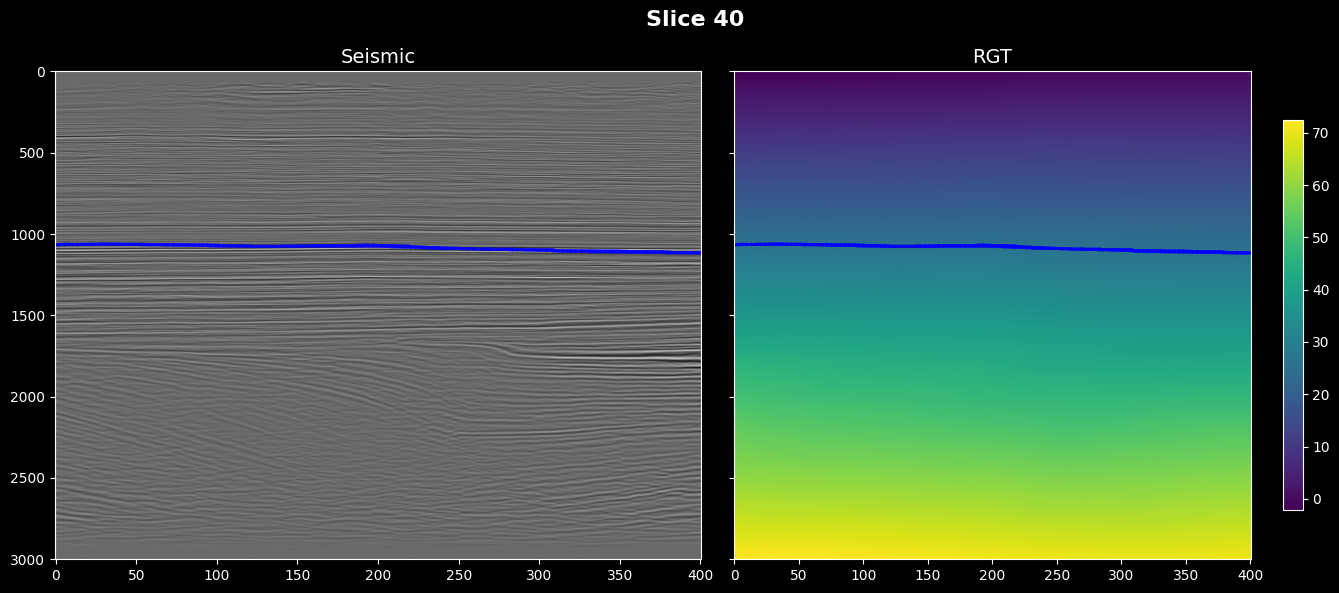

In [24]:
sfile = "../data/Vankorskaya_s_p_5_03-04_Migrirovannyiy_PreStack.sgy"
rgtfile = "../data/predicted_rgt_volume.npy"
print('reading segy')
il_range = (5110, 5510)
xl_range = (1100, 1500)
traces, _, _ = fh.read_sgy_selective(sfile, il_range, xl_range)
gc.collect()
pred_rgt = np.load(rgtfile)

seis_slice = traces[40].T
rgt_slice = pred_rgt[40].T

# Find picks on the 2D slice
eps = 10e-2
target_value = 26
picks = np.where(np.abs(rgt_slice - target_value) <= eps)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axs[0].imshow(seis_slice, cmap='grey', aspect='auto')
axs[0].scatter(picks[1], picks[0], c='blue', s=1, alpha=0.3)
axs[0].set_title('Seismic', fontsize=14)

im = axs[1].imshow(rgt_slice, cmap='viridis', aspect='auto')
axs[1].scatter(picks[1], picks[0], c='blue', s=1, alpha=0.3)
axs[1].set_title('RGT', fontsize=14)
plt.colorbar(im, ax=axs[1], shrink=0.8)

fig.suptitle('Slice 40', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()